In [20]:
import pandas as pd
import numpy as np

### Creating Dataset (YouTube Tutorial)

In [1]:
# https://www.youtube.com/watch?v=sM1mhGVRYI0

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

n = 100
# 1. Generate Age with Nulls
age = np.random.normal(30, 10, n)
age[np.random.randint(0, n, 10)] = np.nan

# 2. Generate Income with extreme outliers
income = np.random.normal(50000, 15000, n)
income[np.random.randint(0, n, 5)] *= 10

# 3. Generate Cities with None/Nulls
cities = np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston'], n)
cities = cities.astype(object) # Ensure it can hold 'None'
cities[np.random.randint(0, n, 8)] = None

# 4. Generate Dates (Fixed the Null logic)
dates = [datetime.today() - timedelta(days=random.randint(0, 365)) for _ in range(n)]
for idx in np.random.randint(0, n, 5):
    dates[idx] = pd.NaT  # Use NaT (Not a Time) for proper pandas date nulls

# 5. Build the DataFrame
df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "City": cities,
    "Joined": dates
})

# 6. Add the Duplicate row
duplicate_idx = 20
duplicated_row = df.iloc[[duplicate_idx]] # Easier way to grab the whole row
df = pd.concat([df, duplicated_row], ignore_index=True)

# 7. Categorical Notes (Fixed '1' to 'i')
df['notes'] = [
    'good customer' if i % 3 == 0 else 'slow-completer' if i % 4 == 0 else 'frequent payer' 
    for i in range(len(df))
]

#print(df.head())
df.head()

,Age,Income,City,Joined,notes
0,NaN,40272.028592,Houston,2025-07-14 10:31:20.606949,good customer
1,48.918117,75626.592484,Chicago,2025-06-29 10:31:20.606997,frequent payer
2,31.397358,62625.389084,Los Angeles,2025-07-11 10:31:20.607017,frequent payer
3,43.475044,539512.138344,Chicago,2026-02-13 10:31:20.607030,good customer
4,18.138351,43060.422189,Los Angeles,2026-02-13 10:31:20.607043,slow-completer


### Standardizing Created Dataset in Pipeline

In [2]:
import pandas as pd

def universal_wash_and_dry(input_df):
    """
    Standardizes any dataset in the Anaphyl Pipeline.
    Handles synthetic test data and real Moodle data.
    """
    df_cleaned = input_df.copy()
    
    # 1. HEADER NORMALIZATION (Always stays the same)
    df_cleaned.columns = [col.lower().replace(' ', '_') for col in df_cleaned.columns]
    
    # 2. DYNAMIC DATE CONVERSION
    # We look for common date keywords so the function 'finds' the right column
    date_keywords = ['date', 'joined', 'access', 'enrolment', 'time']
    for col in df_cleaned.columns:
        if any(key in col for key in date_keywords):
            df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')
    
    # 3. CATEGORICAL FILLING
    # Filling missing Cities in your synthetic data
    if 'city' in df_cleaned.columns:
        df_cleaned['city'] = df_cleaned['city'].fillna('Unknown Location')
        
    # Standardizing 'slow-completers' across 'status' or 'notes'
    target_cols = ['status', 'notes', 'completed']
    for col in target_cols:
        if col in df_cleaned.columns:
            # Ensuring the project terminology is consistent
            df_cleaned[col] = df_cleaned[col].fillna('slow-completers')
            
    return df_cleaned

# EXECUTE ON SYNTHETIC DATA
df_synthetic_final = universal_wash_and_dry(df)

# VERIFICATION
print("--- [REPORT] SYNTHETIC DATA CLEANED ---")
print(df_synthetic_final.info())
print("\n--- NULL CHECK (CITY) ---")
print(df_synthetic_final['city'].value_counts())

--- [REPORT] SYNTHETIC DATA CLEANED ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   age     91 non-null     float64       
 1   income  101 non-null    float64       
 2   city    101 non-null    object        
 3   joined  96 non-null     datetime64[ns]
 4   notes   101 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.1+ KB
None

--- NULL CHECK (CITY) ---
city
Chicago             27
Houston             25
Los Angeles         25
New York            17
Unknown Location     7
Name: count, dtype: int64


#### Testing Pipeline with Other Dataset

In [16]:
import pandas as pd
import numpy as np

# Creating messy Retail Data
retail_data = {
    'Order Date': ['2026-01-01', '02/01/2026', 'Not a Date', '2026-03-01'],
    'Product_Name': ['Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Unit Price': [1200.50, 25.00, np.nan, 75.00],
    'Inventory_Status': ['In Stock', None, 'Backordered', 'In Stock']
}

df_retail = pd.DataFrame(retail_data)

# Adding a duplicate for the 'Duplicate Sweep' test
df_retail = pd.concat([df_retail, df_retail.iloc[[0]]], ignore_index=True)

print("--- RAW RETAIL DATA ---")
print(df_retail)

--- RAW RETAIL DATA ---
   Order Date Product_Name  Unit Price Inventory_Status
0  2026-01-01       Laptop      1200.5         In Stock
1  02/01/2026        Mouse        25.0             None
2  Not a Date      Monitor         NaN      Backordered
3  2026-03-01     Keyboard        75.0         In Stock
4  2026-01-01       Laptop      1200.5         In Stock


#### ... More Pipeline Practice

In [37]:
import pandas as pd

def universal_wash_and_dry(input_df):
    """
    Standardizes any dataset. Corrects for Case-Sensitivity in target columns.
    """
    df_cleaned = input_df.copy()
    
    # 1. HEADER NORMALIZATION (The Foundation)
    df_cleaned.columns = [col.lower().replace(' ', '_') for col in df_cleaned.columns]
    
    # 2. DYNAMIC DATE CONVERSION
    # 'order_date' will be caught by the keyword 'date'
    date_keywords = ['date', 'joined', 'access', 'enrolment', 'time', 'Order Date']
    for col in df_cleaned.columns:
        if any(key in col for key in date_keywords):
            df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')
    
    # 3. CATEGORICAL FILLING (Using Lowercase Names)
    if 'city' in df_cleaned.columns:
        df_cleaned['city'] = df_cleaned['city'].fillna('Unknown Location')
        
    # Standardizing terminology - notice these are now lowercase!
    target_cols = ['status', 'notes', 'completed', 'inventory_status']
    for col in target_cols:
        if col in df_cleaned.columns:
            df_cleaned[col] = df_cleaned[col].fillna('slow-completers')

    # 4. THE DUPLICATE SWEEP
    df_cleaned = df_cleaned.drop_duplicates()
            
    return df_cleaned

# EXECUTE
df_retail_final = universal_wash_and_dry(df_retail)

# VERIFICATION - Use lowercase here too!
print("--- [REPORT] RETAIL DATA CLEANED ---")
print(df_retail_final.info())
print("\n--- NULL CHECK (INVENTORY STATUS) ---")
if 'inventory_status' in df_retail_final.columns:
    print(df_retail_final['inventory_status'].value_counts())

--- [REPORT] RETAIL DATA CLEANED ---
<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_date        2 non-null      datetime64[ns]
 1   product_name      4 non-null      object        
 2   unit_price        3 non-null      float64       
 3   inventory_status  4 non-null      object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 160.0+ bytes
None

--- NULL CHECK (INVENTORY STATUS) ---
inventory_status
In Stock           2
slow-completers    1
Backordered        1
Name: count, dtype: int64


#### Creating 200 'Random' rows of Dataset - STEP BY STEP

In [1]:
##### ONE: ORDER DATE #####

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# 'Order Date'
# 1. n must be an integer (the number of rows)
n = 200 

# 2. Define your range
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 12, 31)
days_between = (end_date - start_date).days

# 3. Generate random dates
random_dates = [start_date + timedelta(days=random.randint(0, days_between)) for _ in range(n)]

# 4. Inject Nulls (NaT) correctly
# We use pd.Series so we can use the .iloc setter or convert it later
dates_series = pd.Series(random_dates)
null_indices = np.random.randint(0, n, 10) # Picking 10 random rows for nulls
dates_series.iloc[null_indices] = pd.NaT

# print(dates_series.head())

##### TOW - 'Product_Name' (The Inventory) #####
# Generating Product_name with None/Nulls
product_name = np.random.choice(['Laptop', 'Mouse', 'Monitor', 'Keyboard', 'PC-bag', 'Charger-cable', 'Lamp', 'Note-pad', 'Pen', 'Batteries'], n)
product_name = product_name.astype(object) # Ensure it can hold 'None'
product_name[np.random.randint(0, n, 10)] = None

# Senior-style precision for your Junior-test:
null_indices = np.random.choice(range(n), size=8, replace=False)
product_name[null_indices] = None


###### 'Unit Price' (The Financials) ######
# 1. Generate the standard prices
unit_price = np.random.normal(25.00, 10.00, n) # Mean of £25, spread of £10

# 2. Pick 5 random row numbers (integers) to become outliers
outlier_indices = np.random.randint(0, n, 5)

# 3. Multiply those specific rows by 10
unit_price[outlier_indices] *= 10


####### 'Inventory_Status' (The Target) ######
# 1. Generate the statuses (Line 1 is already great!)
inventory_status = np.random.choice(['In Stock', 'Backordered', 'Discontinued'], n)

# 2. Ensure it's an object type (Use the SAME variable name)
inventory_status = inventory_status.astype(object) 

# 3. Inject the 10 nulls
inventory_status[np.random.randint(0, n, 10)] = None


####### The Assembly #######
# 5. Build the DataFrame
####### The Assembly #######
df = pd.DataFrame({
    'Order Date': dates_series,     # Fixed: matches your variable above
    'Product_Name': product_name, 
    'Unit Price': unit_price,      
    'Inventory_Status': inventory_status 
})

# Display the result
print(df.head())
print(f"\nTotal rows: {len(df)}")

  Order Date Product_Name  Unit Price Inventory_Status
0 2026-07-27     Note-pad    9.993012     Discontinued
1 2026-11-21     Note-pad   19.488147     Discontinued
2 2026-02-02     Keyboard    8.135792      Backordered
3 2026-09-22        Mouse    8.281373      Backordered
4 2026-11-19     Note-pad   26.033227      Backordered

Total rows: 200


#### Passing the 200 Rows Through the Wash_&_Dry_Function

In [2]:
def universal_wash_and_dry(input_df):
    """
    Standardizes headers, converts dates, and fills nulls.
    """
    # 1. Protection: Create a copy so we don't 'dirty' the original
    df_cleaned = input_df.copy()
    
    # 2. Header Normalization: 'Order Date' -> 'order_date'
    df_cleaned.columns = [col.lower().replace(' ', '_') for col in df_cleaned.columns]
    
    # 3. Dynamic Date Conversion: Finds 'order_date' automatically
    date_keywords = ['date', 'joined', 'enrolment', 'time']
    for col in df_cleaned.columns:
        if any(key in col for key in date_keywords):
            df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')
    
    # 4. Product Name Cleaning: Fills 'None' (like your index 0)
    if 'product_name' in df_cleaned.columns:
        df_cleaned['product_name'] = df_cleaned['product_name'].fillna('Unknown Item')
    
    # 5. Inventory Status Cleaning: Fills 'None' (like your index 3)
    if 'inventory_status' in df_cleaned.columns:
        df_cleaned['inventory_status'] = df_cleaned['inventory_status'].fillna('slow-completers')
        
    # 6. Duplicate Sweep
    df_cleaned = df_cleaned.drop_duplicates()
            
    return df_cleaned

# --- EXECUTION ---
# Pass your raw 200-row dataframe through the machine
df_retail_final = universal_wash_and_dry(df)

# Check the results
print("--- HEADERS CLEANED ---")
print(df_retail_final.columns.tolist())
print("\n--- SAMPLE CLEANED DATA ---")
print(df_retail_final.head())

--- HEADERS CLEANED ---
['order_date', 'product_name', 'unit_price', 'inventory_status']

--- SAMPLE CLEANED DATA ---
  order_date product_name  unit_price inventory_status
0 2026-07-27     Note-pad    9.993012     Discontinued
1 2026-11-21     Note-pad   19.488147     Discontinued
2 2026-02-02     Keyboard    8.135792      Backordered
3 2026-09-22        Mouse    8.281373      Backordered
4 2026-11-19     Note-pad   26.033227      Backordered


In [33]:
###### OPTIONAL ######
# 1. Check how many 'None' entries actually exist
actual_nulls = pd.Series(product_name).isnull().sum()
print(f"Number of None values created: {actual_nulls}")

# 2. Run your cleaning function
# (Assuming df is the dataframe containing your product_name column)
df_cleaned = universal_wash_and_dry(df)

# 3. Check if they were filled
# Ensure your function has a step to fill 'product_name' nulls!
if 'product_name' in df_cleaned.columns:
    print("\n--- After Cleaning ---")
    print(df_cleaned['product_name'].value_counts().get('slow-completers', 0))

Number of None values created: 17

--- After Cleaning ---
0


## Automated Validation

In [3]:
def validate_intelligence_unit(df):
    """
    Stage 4: Automated Validation.
    Checks for logical impossibilities in the dataset.
    """
    print("--- [STAGE 4] VALIDATION REPORT ---")
    
    # 1. Check for Negative Prices
    negative_prices = df[df['unit_price'] < 0].shape[0]
    if negative_prices > 0:
        print(f"⚠️ ALERT: Found {negative_prices} rows with negative prices!")
    else:
        print("✅ Prices: All values are non-negative.")

    # 2. Check for Future Dates
    current_year = 2026
    future_dates = df[df['order_date'].dt.year > current_year].shape[0]
    if future_dates > 0:
        print(f"⚠️ ALERT: Found {future_dates} rows with future dates!")
    else:
        print(f"✅ Dates: All orders are within or before {current_year}.")

    # 3. Check for Outliers
    price_mean = df['unit_price'].mean()
    outliers = df[df['unit_price'] > (price_mean * 5)].shape[0]
    if outliers > 0:
        print(f"ℹ️ NOTE: Found {outliers} extreme price outliers.")

# --- THE EXECUTION (This MUST be outside the function) ---
validate_intelligence_unit(df_retail_final)

--- [STAGE 4] VALIDATION REPORT ---
⚠️ ALERT: Found 3 rows with negative prices!
✅ Dates: All orders are within or before 2026.
ℹ️ NOTE: Found 5 extreme price outliers.


### "Quick-Win" Analysis Code

In [5]:
# 1. Revenue Analysis by Product
# We calculate a new column for total value per row
df_retail_final['total_value'] = df_retail_final['unit_price']

analysis_summary = df_retail_final.groupby('product_name').agg(
    total_orders=('unit_price', 'count'),
    avg_price=('unit_price', 'mean'),
    inventory_mix=('inventory_status', lambda x: x.value_counts().index[0])
).reset_index()

print("--- STAGE 5: PRODUCT INSIGHTS ---")
print(analysis_summary)

--- STAGE 5: PRODUCT INSIGHTS ---
     product_name  total_orders  avg_price inventory_mix
0       Batteries            17  25.840772      In Stock
1   Charger-cable            18  44.253744      In Stock
2        Keyboard            16  37.330958  Discontinued
3            Lamp            13  25.552186      In Stock
4          Laptop            21  28.623173  Discontinued
5         Monitor            25  20.558832      In Stock
6           Mouse            12  23.737568   Backordered
7        Note-pad            24  24.646282      In Stock
8          PC-bag            19  34.940774  Discontinued
9             Pen            18  41.402138  Discontinued
10   Unknown Item            17  44.988059      In Stock


### Executive Findings

In [ ]:
# The Monitor stands out with 25 (for total_orders) and it's still 'In Stock'


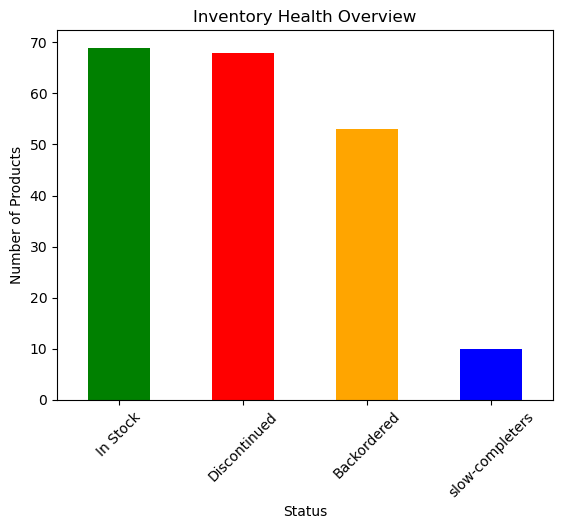

In [7]:
import matplotlib.pyplot as plt

# 1. Visualize the Inventory Status across the whole dataset
df_retail_final['inventory_status'].value_counts().plot(kind='bar', color=['green', 'red', 'orange', 'blue'])

plt.title('Inventory Health Overview')
plt.xlabel('Status')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()